In [34]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import sys
from datetime import datetime

In [4]:
# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Pandas version: 2.2.3
NumPy version: 2.1.3


In [5]:
# Loading Raw Data


# Define file paths
data_path = 'C:/Users/HP/Desktop/AdventureWorks_2022/data/raw/'

# Load all CSV files
try:
    # Load dimension tables
    df_product = pd.read_csv(data_path + 'Product.csv', delimiter='\t')
    df_region = pd.read_csv(data_path + 'Region.csv', delimiter='\t')
    df_reseller = pd.read_csv(data_path + 'Reseller.csv', delimiter='\t')
    df_salesperson = pd.read_csv(data_path + 'Salesperson.csv', delimiter='\t')
    df_salesperson_region = pd.read_csv(data_path + 'SalespersonRegion.csv', delimiter='\t')
    df_targets = pd.read_csv(data_path + 'Targets.csv', delimiter='\t')
    
    # Load fact table
    df_sales = pd.read_csv(data_path + 'Sales.csv', delimiter='\t')
    
    print("All files loaded successfully!")
    print("\nDataset Shapes:")
    print(f"Product: {df_product.shape}")
    print(f"Region: {df_region.shape}")
    print(f"Reseller: {df_reseller.shape}")
    print(f"Sales: {df_sales.shape}")
    print(f"Salesperson: {df_salesperson.shape}")
    print(f"SalespersonRegion: {df_salesperson_region.shape}")
    print(f"Targets: {df_targets.shape}")
    
except Exception as e:
    print(f"Error loading files: {e}")

All files loaded successfully!

Dataset Shapes:
Product: (397, 8)
Region: (10, 4)
Reseller: (701, 6)
Sales: (57851, 10)
Salesperson: (18, 5)
SalespersonRegion: (39, 2)
Targets: (809, 3)


In [6]:
#Data Exploration - Initial Inspection

print("="*60)
print("PRODUCT TABLE")
print("="*60)
print(df_product.head())
print("\nInfo:")
print(df_product.info())
print("\nMissing Values:")
print(df_product.isnull().sum())

print("\n" + "="*60)
print("SALES TABLE")
print("="*60)
print(df_sales.head())
print("\nInfo:")
print(df_sales.info())
print("\nMissing Values:")
print(df_sales.isnull().sum())

print("\n" + "="*60)
print("REGION TABLE")
print("="*60)
print(df_region.head())
print("\nInfo:")
print(df_region.info())
print("\nMissing Values:")
print(df_region.isnull().sum())

print("\n" + "="*60)
print("RESELLER TABLE")
print("="*60)
print(df_reseller.head())
print("\nInfo:")
print(df_reseller.info())
print("\nMissing Values:")
print(df_reseller.isnull().sum())

print("\n" + "="*60)
print("SALESPERSON TABLE")
print("="*60)
print(df_salesperson.head())
print("\nInfo:")
print(df_salesperson.info())
print("\nMissing Values:")
print(df_salesperson.isnull().sum())

PRODUCT TABLE
   ProductKey                    Product Standard Cost  Color  Subcategory  \
0         210  HL Road Frame - Black, 58       $868.63  Black  Road Frames   
1         215    Sport-100 Helmet, Black        $12.03  Black      Helmets   
2         216    Sport-100 Helmet, Black        $13.88  Black      Helmets   
3         217    Sport-100 Helmet, Black        $13.09  Black      Helmets   
4         253  LL Road Frame - Black, 58        $176.2  Black  Road Frames   

      Category Background Color Format Font Color Format  
0   Components                 #000000           #FFFFFF  
1  Accessories                 #000000           #FFFFFF  
2  Accessories                 #000000           #FFFFFF  
3  Accessories                 #000000           #FFFFFF  
4   Components                 #000000           #FFFFFF  

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 

In [7]:
# Data Cleaning & Transformation

# 1. Clean Product Table
print("Cleaning Product table...")
# Remove $ and commas from StandardCost
df_product['Standard Cost'] = df_product['Standard Cost'].replace('[\$,]', '', regex=True).astype(float)
print("Product StandardCost cleaned")

# 2. Clean Sales Table
print("\nCleaning Sales table...")
# Remove $ and commas from currency columns
df_sales['Unit Price'] = df_sales['Unit Price'].replace('[\$,]', '', regex=True).astype(float)
df_sales['Sales'] = df_sales['Sales'].replace('[\$,]', '', regex=True).astype(float)
df_sales['Cost'] = df_sales['Cost'].replace('[\$,]', '', regex=True).astype(float)


# Convert OrderDate to datetime
df_sales['OrderDate'] = pd.to_datetime(df_sales['OrderDate'])
print("Sales currency columns and dates cleaned")


# 3. Clean Targets Table
print("\nCleaning Targets table...")
df_targets['Target'] = df_targets['Target'].replace('[\$,]', '', regex=True).astype(float)
df_targets['TargetMonth'] = pd.to_datetime(df_targets['TargetMonth'])
print("Targets cleaned")

# 4. Handle Missing Values
print("\nChecking for missing values...")
print("\nProduct missing values:")
print(df_product.isnull().sum())
print("\nSales missing values:")
print(df_sales.isnull().sum())

# Fill missing colors with 'Not Specified'
df_product['Color'].fillna('Not Specified', inplace=True)

print("\nData cleaning completed!")

Cleaning Product table...
Product StandardCost cleaned

Cleaning Sales table...
Sales currency columns and dates cleaned

Cleaning Targets table...
Targets cleaned

Checking for missing values...

Product missing values:
ProductKey                  0
Product                     0
Standard Cost               0
Color                      56
Subcategory                 0
Category                    0
Background Color Format     0
Font Color Format           0
dtype: int64

Sales missing values:
SalesOrderNumber     0
OrderDate            0
ProductKey           0
ResellerKey          0
EmployeeKey          0
SalesTerritoryKey    0
Quantity             0
Unit Price           0
Sales                0
Cost                 0
dtype: int64

Data cleaning completed!


In [8]:
#Creating Features

print("Creating new features...")

# 1. Extract Date Features from Sales
df_sales['Year'] = df_sales['OrderDate'].dt.year
df_sales['Quarter'] = df_sales['OrderDate'].dt.quarter
df_sales['Month'] = df_sales['OrderDate'].dt.month
df_sales['MonthName'] = df_sales['OrderDate'].dt.month_name()
df_sales['DayOfWeek'] = df_sales['OrderDate'].dt.day_name()
df_sales['WeekOfYear'] = df_sales['OrderDate'].dt.isocalendar().week

# 2. Calculate Profit in Sales
df_sales['Profit'] = df_sales['Sales'] - df_sales['Cost']
df_sales['ProfitMargin'] = (df_sales['Profit'] / df_sales['Sales']) * 100

# 3. Calculate Revenue per Unit
df_sales['RevenuePerUnit'] = df_sales['Sales'] / df_sales['Quantity']

# 4. Extract Date Features from Targets
df_targets['Year'] = df_targets['TargetMonth'].dt.year
df_targets['Month'] = df_targets['TargetMonth'].dt.month

print("Feature engineering completed!")
print("\nNew columns in Sales table:")
print(df_sales.columns.tolist())
print("\nSales table shape:", df_sales.shape)
print("\nSample data:")
print(df_sales[['OrderDate', 'Year', 'Quarter', 'Month', 'Sales', 'Cost', 'Profit', 'ProfitMargin']].head())

Creating new features...
Feature engineering completed!

New columns in Sales table:
['SalesOrderNumber', 'OrderDate', 'ProductKey', 'ResellerKey', 'EmployeeKey', 'SalesTerritoryKey', 'Quantity', 'Unit Price', 'Sales', 'Cost', 'Year', 'Quarter', 'Month', 'MonthName', 'DayOfWeek', 'WeekOfYear', 'Profit', 'ProfitMargin', 'RevenuePerUnit']

Sales table shape: (57851, 19)

Sample data:
   OrderDate  Year  Quarter  Month   Sales    Cost  Profit  ProfitMargin
0 2017-08-25  2017        3      8   57.68   63.45   -5.77        -10.00
1 2017-08-25  2017        3      8 4049.98 3796.19  253.79          6.27
2 2017-08-25  2017        3      8 4049.98 3796.19  253.79          6.27
3 2017-08-25  2017        3      8   57.68   63.45   -5.77        -10.00
4 2017-11-18  2017        4     11 1637.40 1413.62  223.78         13.67


In [9]:
#  Create Master Dataset(Merging Dataeset)

print("Merging all tables into master dataset...")

# Merge Sales with Product
df_master = df_sales.merge(
    df_product[['ProductKey', 'Product', 'Category', 'Subcategory', 'Color', 'Standard Cost']], 
    on='ProductKey', 
    how='left'
)

# Merge with Region
df_master = df_master.merge(
    df_region, 
    on='SalesTerritoryKey', 
    how='left'
)


# Merge with Reseller
df_master = df_master.merge(
    df_reseller[['ResellerKey', 'Business Type', 'Reseller', 'City', 'State-Province', 'Country-Region']], 
    on='ResellerKey', 
    how='left'
)

# Merge with Salesperson
df_master = df_master.merge(
    df_salesperson[['EmployeeKey', 'Salesperson', 'Title']], 
    on='EmployeeKey', 
    how='left'
)

print("Master dataset created!")
print(f"\nMaster dataset shape: {df_master.shape}")
print(f"Columns: {df_master.shape[1]}")
print(f"Rows: {df_master.shape[0]}")

print("\nColumn names:")
print(df_master.columns.tolist())

print("\nFirst few rows:")
print(df_master.head())

Merging all tables into master dataset...
Master dataset created!

Master dataset shape: (57851, 34)
Columns: 34
Rows: 57851

Column names:
['SalesOrderNumber', 'OrderDate', 'ProductKey', 'ResellerKey', 'EmployeeKey', 'SalesTerritoryKey', 'Quantity', 'Unit Price', 'Sales', 'Cost', 'Year', 'Quarter', 'Month', 'MonthName', 'DayOfWeek', 'WeekOfYear', 'Profit', 'ProfitMargin', 'RevenuePerUnit', 'Product', 'Category', 'Subcategory', 'Color', 'Standard Cost', 'Region', 'Country', 'Group', 'Business Type', 'Reseller', 'City', 'State-Province', 'Country-Region', 'Salesperson', 'Title']

First few rows:
  SalesOrderNumber  OrderDate  ProductKey  ResellerKey  EmployeeKey  \
0          SO43897 2017-08-25         235          312          282   
1          SO43897 2017-08-25         351          312          282   
2          SO43897 2017-08-25         348          312          282   
3          SO43897 2017-08-25         232          312          282   
4          SO44544 2017-11-18         292  

In [10]:
#Data Analysis

print("="*60)
print("STATISTICAL SUMMARY")
print("="*60)

# Numerical columns summary
print("\nSales Metrics Summary:")
print(df_master[['Quantity', 'Unit Price', 'Sales', 'Cost', 'Profit', 'ProfitMargin']].describe())

# Additional statistics
print("\nRevenue Statistics:")
print(f"Total Revenue: ${df_master['Sales'].sum():,.2f}")
print(f"Total Profit: ${df_master['Profit'].sum():,.2f}")
print(f"Total Cost: ${df_master['Cost'].sum():,.2f}")
print(f"Average Profit Margin: {df_master['ProfitMargin'].mean():.2f}%")
print(f"Total Orders: {df_master['SalesOrderNumber'].nunique():,}")
print(f"Total Quantity Sold: {df_master['Quantity'].sum():,}")

print("\nDate Range:")
print(f"First Order: {df_master['OrderDate'].min()}")
print(f"Last Order: {df_master['OrderDate'].max()}")
print(f"Analysis Period: {(df_master['OrderDate'].max() - df_master['OrderDate'].min()).days} days")

print("\nBusiness Dimensions:")
print(f"Unique Products: {df_master['Product'].nunique()}")
print(f"Unique Categories: {df_master['Category'].nunique()}")
print(f"Unique Resellers: {df_master['Reseller'].nunique()}")
print(f"Unique Salespeople: {df_master['Salesperson'].nunique()}")
print(f"Unique Regions: {df_master['Region'].nunique()}")
print(f"Unique Countries: {df_master['Country'].nunique()}")

STATISTICAL SUMMARY

Sales Metrics Summary:
       Quantity  Unit Price    Sales     Cost    Profit  ProfitMargin
count  57851.00    57851.00 57851.00 57851.00  57851.00      57851.00
mean       3.53      446.39  1340.49  1323.21     17.28          8.97
std        3.04      521.88  2151.75  2169.79    324.00         20.78
min        1.00        1.33     1.37     0.86 -11597.79       -172.76
25%        2.00       34.93   129.56    97.15    -18.36         -3.60
50%        3.00      214.24   469.79   461.44     13.84          7.65
75%        4.00      672.29  1516.16  1510.30     58.82         26.00
max       44.00     2146.96 30993.04 38530.39   1278.36         40.44

Revenue Statistics:
Total Revenue: $77,548,570.20
Total Profit: $999,494.57
Total Cost: $76,549,075.63
Average Profit Margin: 8.97%
Total Orders: 3,616
Total Quantity Sold: 204,114

Date Range:
First Order: 2017-07-01 00:00:00
Last Order: 2020-05-31 00:00:00
Analysis Period: 1065 days

Business Dimensions:
Unique Products: 

In [11]:
#Distribution Analysis

print("Analyzing distributions...")

# Category Distribution
print("\nSales by Category:")
category_sales = df_master.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
    'SalesOrderNumber': 'nunique'
}).round(2)
category_sales.columns = ['Total_Sales', 'Total_Profit', 'Total_Quantity', 'Total_Orders']
category_sales = category_sales.sort_values('Total_Sales', ascending=False)
print(category_sales)

# Region Distribution
print("\nSales by Region:")
region_sales = df_master.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'SalesOrderNumber': 'nunique'
}).round(2)
region_sales.columns = ['Total_Sales', 'Total_Profit', 'Total_Orders']
region_sales = region_sales.sort_values('Total_Sales', ascending=False)
print(region_sales)

# Business Type Distribution
print("\nSales by Business Type:")
business_sales = df_master.groupby('Business Type').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).round(2)
business_sales.columns = ['Total_Sales', 'Total_Profit']
business_sales = business_sales.sort_values('Total_Sales', ascending=False)
print(business_sales)

Analyzing distributions...

Sales by Category:
             Total_Sales  Total_Profit  Total_Quantity  Total_Orders
Category                                                            
Bikes        64069033.16    -435678.90           71880          3009
Components   11226374.90    1001235.43           46472          2505
Clothing      1714056.05     245857.28           61498          2299
Accessories    539106.09     188080.76           24264          1249

Sales by Region:
                Total_Sales  Total_Profit  Total_Orders
Region                                                 
Southwest       18001116.10     110750.76           717
Canada          13875632.96     255576.41           658
Northwest       12004822.45     304235.84           513
Southeast        7638606.55     168495.82           455
Central          7633386.86     165349.24           363
Northeast        6715354.39     109598.52           331
France           4527839.69       5332.16           179
United Kingdom   

In [12]:
#Correlation Analysis

print("Analyzing correlations between numerical variables...")

# Select numerical columns
numerical_cols = ['Quantity', 'Unit Price', 'Sales', 'Cost', 'Profit', 'ProfitMargin']
correlation_matrix = df_master[numerical_cols].corr()

print("\nCorrelation Matrix:")
print(correlation_matrix.round(3))

# Identify strong correlations
print("\nStrong Correlations (|r| > 0.7):")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            print(f"{correlation_matrix.columns[i]} <-> {correlation_matrix.columns[j]}: {corr_value:.3f}")

Analyzing correlations between numerical variables...

Correlation Matrix:
              Quantity  Unit Price  Sales  Cost  Profit  ProfitMargin
Quantity          1.00       -0.15   0.24  0.24   -0.03          0.06
Unit Price       -0.15        1.00   0.72  0.71    0.06         -0.31
Sales             0.24        0.72   1.00  0.99    0.02         -0.23
Cost              0.24        0.71   0.99  1.00   -0.13         -0.29
Profit           -0.03        0.06   0.02 -0.13    1.00          0.41
ProfitMargin      0.06       -0.31  -0.23 -0.29    0.41          1.00

Strong Correlations (|r| > 0.7):
Unit Price <-> Sales: 0.722
Unit Price <-> Cost: 0.707
Sales <-> Cost: 0.989


In [13]:
#Time Series Analysis

print("Analyzing sales trends over time...")

# Monthly Sales Trend
monthly_sales = df_master.groupby(df_master['OrderDate'].dt.to_period('M')).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
    'SalesOrderNumber': 'nunique'
}).round(2)
monthly_sales.index = monthly_sales.index.to_timestamp()
monthly_sales.columns = ['Total_Sales', 'Total_Profit', 'Total_Quantity', 'Total_Orders']

print("\nMonthly Sales Summary:")
print(monthly_sales.tail(12))

# Yearly Sales Trend
yearly_sales = df_master.groupby('Year').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
    'SalesOrderNumber': 'nunique'
}).round(2)
yearly_sales.columns = ['Total_Sales', 'Total_Profit', 'Total_Quantity', 'Total_Orders']

print("\nYearly Sales Summary:")
print(yearly_sales)

# Calculate Year-over-Year Growth
yearly_sales['Sales_Growth_%'] = yearly_sales['Total_Sales'].pct_change() * 100
yearly_sales['Profit_Growth_%'] = yearly_sales['Total_Profit'].pct_change() * 100

print("\nYear-over-Year Growth:")
print(yearly_sales[['Total_Sales', 'Sales_Growth_%', 'Total_Profit', 'Profit_Growth_%']].round(2))

Analyzing sales trends over time...

Monthly Sales Summary:
            Total_Sales  Total_Profit  Total_Quantity  Total_Orders
OrderDate                                                          
2019-06-01   1990249.25     102784.47            6123           102
2019-07-01   2729167.03    -118341.29            9871            94
2019-08-01   4306549.14    -157244.56           15139           185
2019-09-01   4153399.35    -172100.02           14774           176
2019-10-01   2293200.43       7853.14            7457            99
2019-11-01   3490438.03      29682.42           10584           178
2019-12-01   3516971.30      37011.23           10574           176
2020-01-01   1664187.50       6225.06            4637            94
2020-02-01   2701954.05      14284.23            6370           174
2020-03-01   2741182.95       9172.93            6594           174
2020-04-01   2214090.83      12331.19            7136            93
2020-05-01   3328607.46     -12290.12           10129   

In [14]:
#Top Performers Analysis

print("Identifying top performers...")

# Top 10 Products
print("\nTop 10 Products by Revenue:")
top_products = df_master.groupby('Product').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).round(2)
top_products.columns = ['Total_Sales', 'Total_Profit', 'Total_Quantity']
top_products = top_products.sort_values('Total_Sales', ascending=False).head(10)
print(top_products)

# Top 10 Resellers
print("\nTop 10 Resellers by Revenue:")
top_resellers = df_master.groupby('Reseller').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'SalesOrderNumber': 'nunique'
}).round(2)
top_resellers.columns = ['Total_Sales', 'Total_Profit', 'Total_Orders']
top_resellers = top_resellers.sort_values('Total_Sales', ascending=False).head(10)
print(top_resellers)

# Top 10 Salespeople
print("\nTop 10 Salespeople by Revenue:")
top_salespeople = df_master.groupby('Salesperson').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'SalesOrderNumber': 'nunique'
}).round(2)
top_salespeople.columns = ['Total_Sales', 'Total_Profit', 'Total_Orders']
top_salespeople = top_salespeople.sort_values('Total_Sales', ascending=False).head(10)
print(top_salespeople)

# Top Countries
print("\nTop 5 Countries by Revenue:")
top_countries = df_master.groupby('Country').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).round(2)
top_countries.columns = ['Total_Sales', 'Total_Profit']
top_countries = top_countries.sort_values('Total_Sales', ascending=False).head(5)
print(top_countries)

Identifying top performers...

Top 10 Products by Revenue:
                         Total_Sales  Total_Profit  Total_Quantity
Product                                                           
Mountain-200 Black, 38    2944665.88     272773.86            2274
Mountain-200 Black, 42    2517355.08     234485.77            1953
Mountain-200 Silver, 38   2240091.34     210455.61            1714
Mountain-200 Silver, 42   2108685.83     198461.78            1620
Mountain-200 Silver, 46   2038938.83     193576.11            1567
Mountain-200 Black, 46    1845368.54     174514.55            1424
Road-250 Black, 44        1832750.05     -63211.17            1332
Road-250 Black, 48        1586672.94     -53761.27            1152
Road-350-W Yellow, 48     1283443.06     -98922.21            1277
Touring-1000 Blue, 60     1263913.32     -59457.47             893

Top 10 Resellers by Revenue:
                                    Total_Sales  Total_Profit  Total_Orders
Reseller                       

In [15]:
#Visualizations Functions

def save_plot(filename):
    """Save plot to absolute outputs folder"""
    save_path = r"C:\Users\HP\Desktop\AdventureWorks_2022\outputs\charts"
    
    # Create the folder if it doesn't exist
    os.makedirs(save_path, exist_ok=True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, filename), dpi=300, bbox_inches='tight')
    print(f"Saved: {os.path.join(save_path, filename)}")

# def format_currency(x, pos):
#     """Format numbers as currency"""
#     return f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'

def format_currency(x, pos):
    """Format numbers as currency"""
    if x >= 1e6:
        return f'${x/1e6:.1f}M'
    elif x >= 1e3:
        return f'${x/1e3:.0f}K'
    else:
        return f'${x:.0f}'

# def format_number(x, pos):
#     """Format large numbers"""
#     return f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'


def format_number(x, pos):
    """Format large numbers"""
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    elif x >= 1e3:
        return f'{x/1e3:.0f}K'
    else:
        return f'{x:.0f}'

print("Visualization functions created!")

Visualization functions created!


Saved: C:\Users\HP\Desktop\AdventureWorks_2022\outputs\charts\01_monthly_sales_trend.png


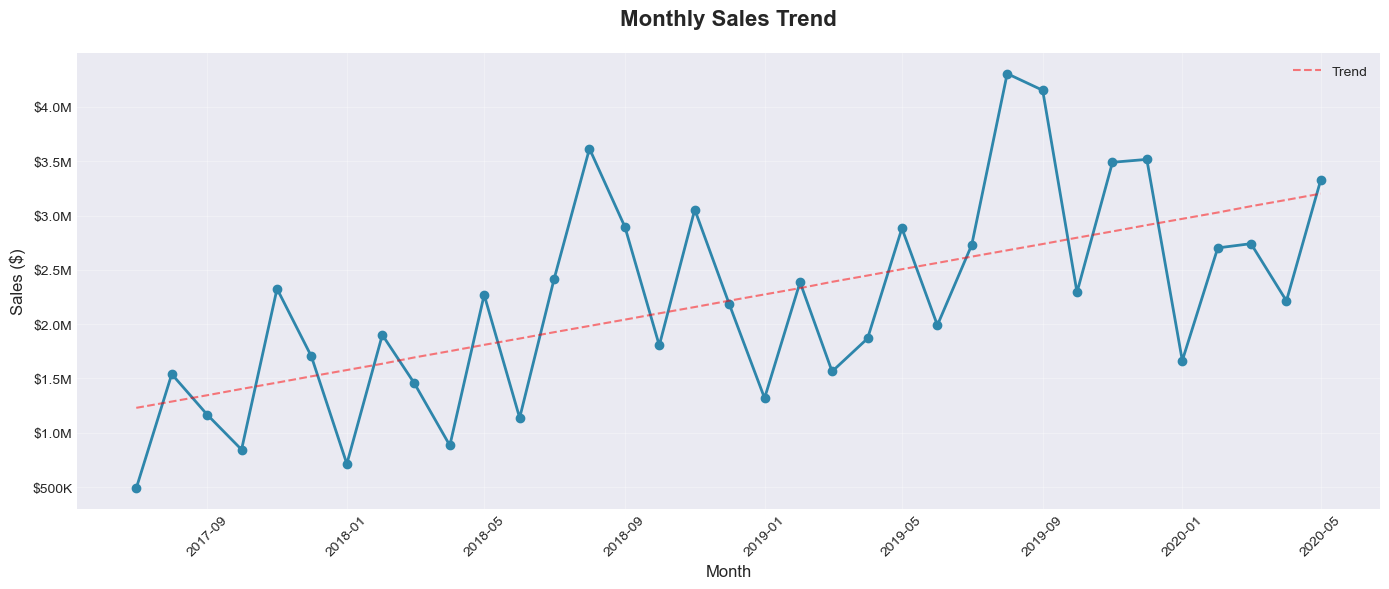

Chart 1 completed!


In [16]:
#Visualization: Monthly Sales Trend


plt.figure(figsize=(14, 6))
plt.plot(monthly_sales.index, monthly_sales['Total_Sales'], marker='o', linewidth=2, markersize=6, color='#2E86AB')
plt.title('Monthly Sales Trend', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Add trend line
z = np.polyfit(range(len(monthly_sales)), monthly_sales['Total_Sales'], 1)
p = np.poly1d(z)
plt.plot(monthly_sales.index, p(range(len(monthly_sales))), "r--", alpha=0.5, label='Trend')
plt.legend()

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_currency))
save_plot('01_monthly_sales_trend.png')
plt.show()

print("Chart 1 completed!")

Saved: C:\Users\HP\Desktop\AdventureWorks_2022\outputs\charts\02_sales_by_category_pie.png


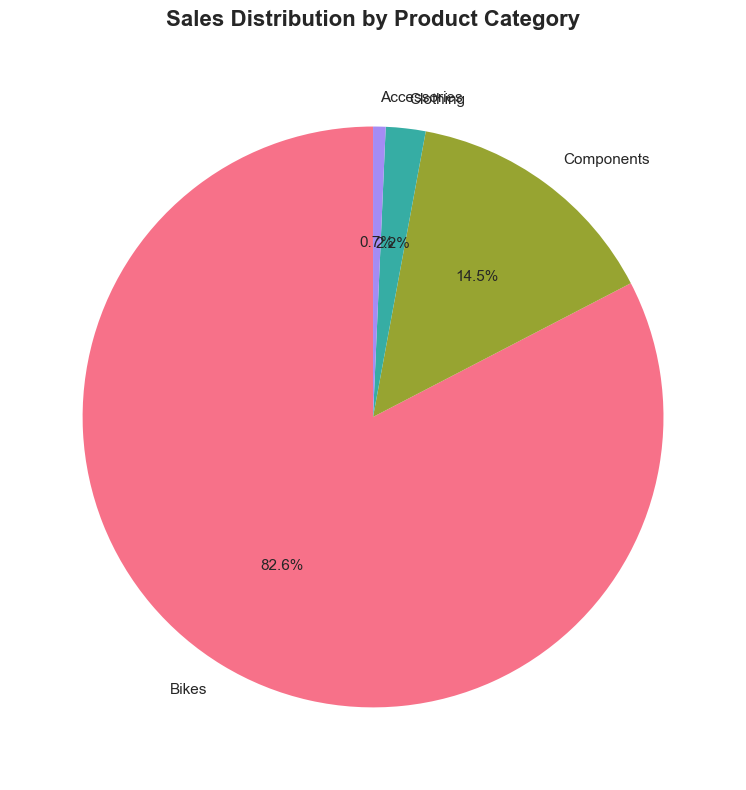

Chart 2 completed!


In [17]:
# Visualization: Sales by Category (Pie Chart)

plt.figure(figsize=(10, 8))
colors = sns.color_palette('husl', len(category_sales))
plt.pie(category_sales['Total_Sales'], 
        labels=category_sales.index, 
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        textprops={'fontsize': 11})
plt.title('Sales Distribution by Product Category', fontsize=16, fontweight='bold', pad=20)
save_plot('02_sales_by_category_pie.png')
plt.show()

print("Chart 2 completed!")

Saved: C:\Users\HP\Desktop\AdventureWorks_2022\outputs\charts\03_sales_by_category_bar.png


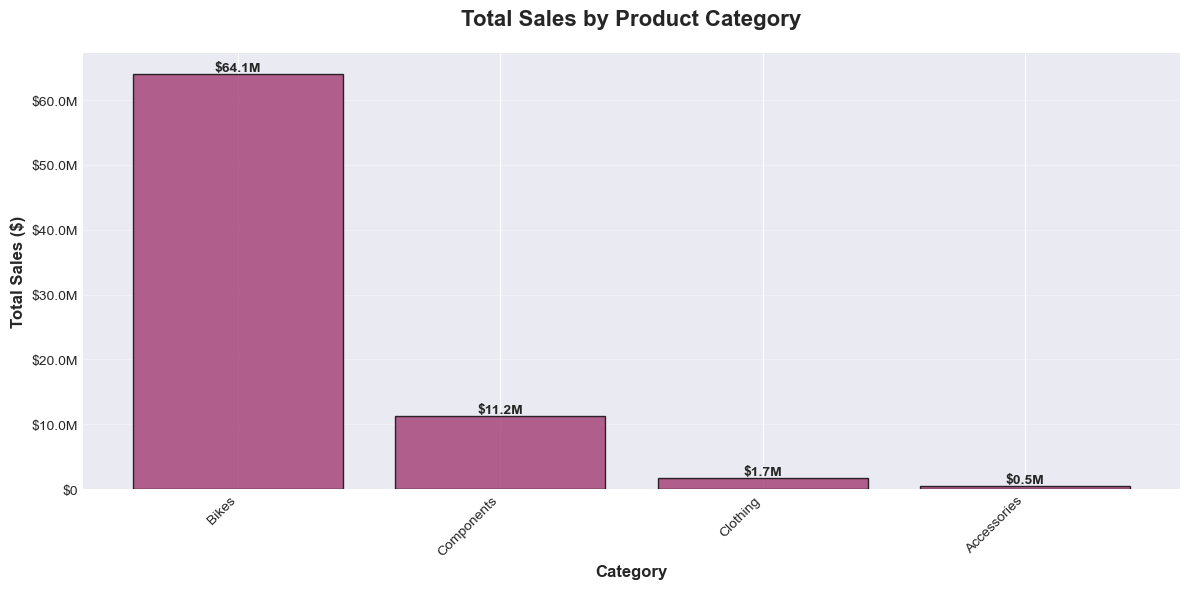

Chart 3 completed!


In [18]:
# Visualization: Category Performance (Bar Chart)

plt.figure(figsize=(12, 6))
x_pos = np.arange(len(category_sales))
plt.bar(x_pos, category_sales['Total_Sales'], color='#A23B72', alpha=0.8, edgecolor='black')
plt.xlabel('Category', fontsize=12, fontweight='bold')
plt.ylabel('Total Sales ($)', fontsize=12, fontweight='bold')
plt.title('Total Sales by Product Category', fontsize=16, fontweight='bold', pad=20)
plt.xticks(x_pos, category_sales.index, rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(category_sales['Total_Sales']):
    plt.text(i, v, f'${v/1e6:.1f}M', ha='center', va='bottom', fontweight='bold')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_currency))
save_plot('03_sales_by_category_bar.png')
plt.show()

print("Chart 3 completed!")

Saved: C:\Users\HP\Desktop\AdventureWorks_2022\outputs\charts\04_top10_products.png


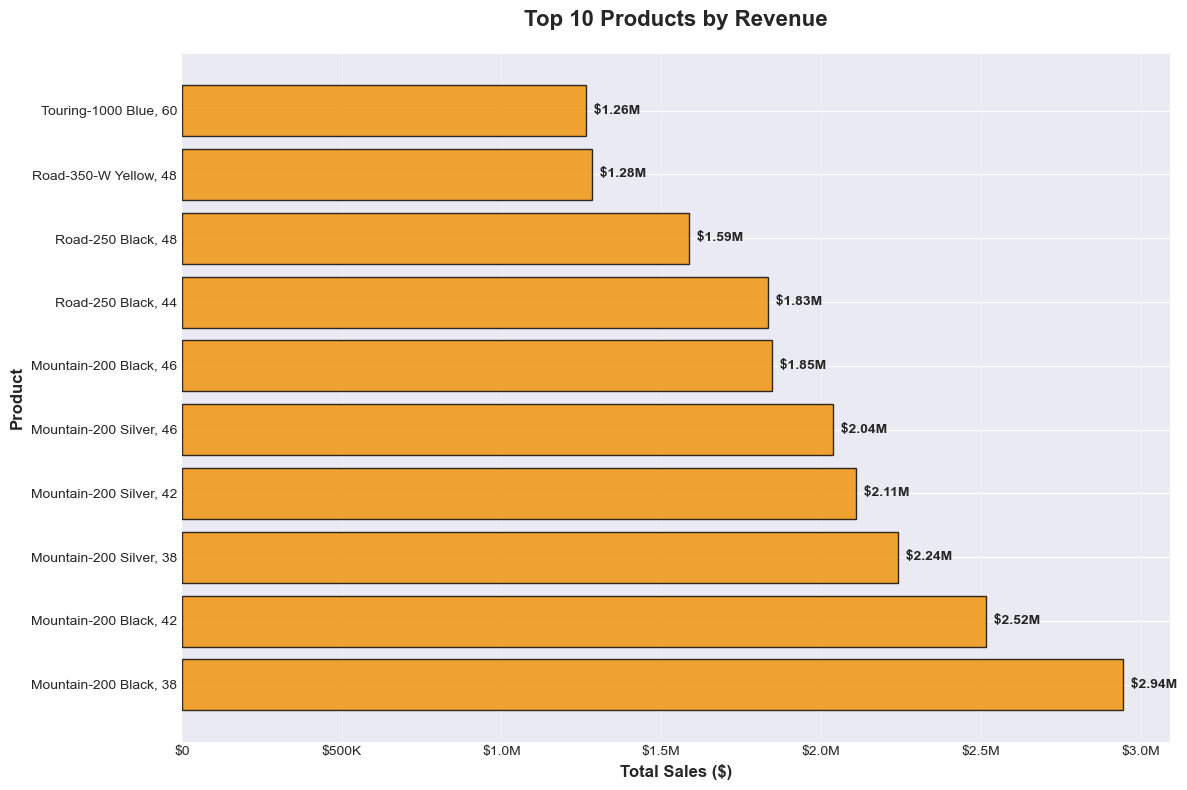

Chart 4 completed!


In [20]:
# Visualization: Top 10 Products (Horizontal Bar)

plt.figure(figsize=(12, 8))
y_pos = np.arange(len(top_products))
plt.barh(y_pos, top_products['Total_Sales'], color='#F18F01', alpha=0.8, edgecolor='black')
plt.xlabel('Total Sales ($)', fontsize=12, fontweight='bold')
plt.ylabel('Product', fontsize=12, fontweight='bold')
plt.title('Top 10 Products by Revenue', fontsize=16, fontweight='bold', pad=20)
plt.yticks(y_pos, top_products.index, fontsize=10)
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(top_products['Total_Sales']):
    plt.text(v, i, f'  ${v/1e6:.2f}M', va='center', fontweight='bold')

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_currency))
save_plot('04_top10_products.png')
plt.show()

print("Chart 4 completed!")

Saved: C:\Users\HP\Desktop\AdventureWorks_2022\outputs\charts\05_sales_by_region.png


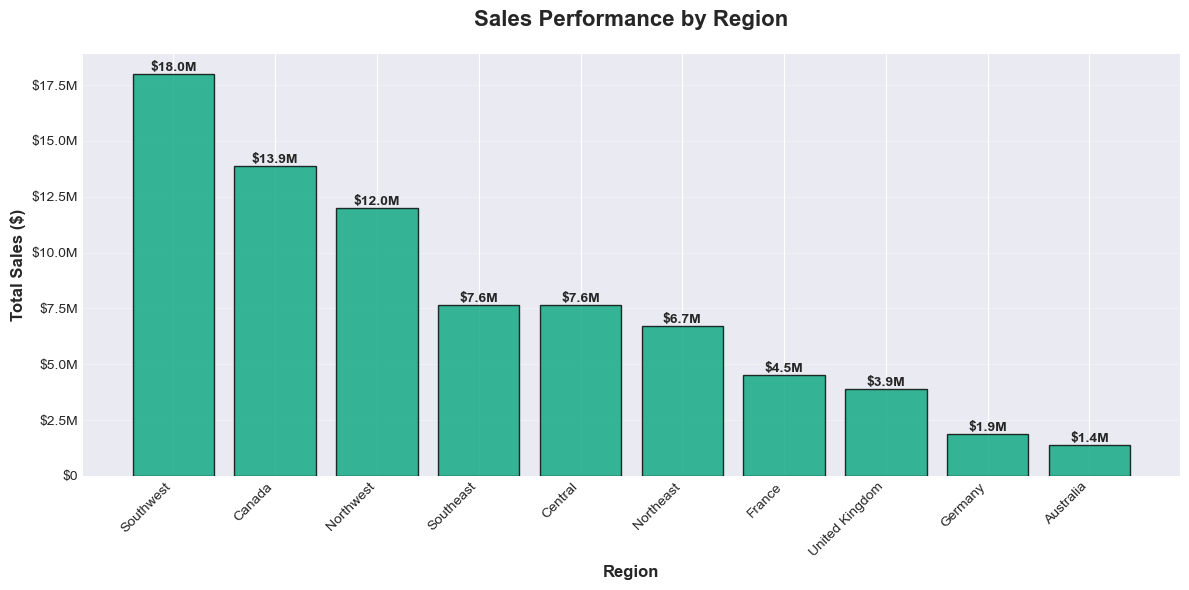

Chart 5 completed!


In [21]:
# Visualization: Sales by Region (Bar Chart)

plt.figure(figsize=(12, 6))
x_pos = np.arange(len(region_sales))
plt.bar(x_pos, region_sales['Total_Sales'], color='#06A77D', alpha=0.8, edgecolor='black')
plt.xlabel('Region', fontsize=12, fontweight='bold')
plt.ylabel('Total Sales ($)', fontsize=12, fontweight='bold')
plt.title('Sales Performance by Region', fontsize=16, fontweight='bold', pad=20)
plt.xticks(x_pos, region_sales.index, rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(region_sales['Total_Sales']):
    plt.text(i, v, f'${v/1e6:.1f}M', ha='center', va='bottom', fontweight='bold')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_currency))
save_plot('05_sales_by_region.png')
plt.show()

print("Chart 5 completed!")

Saved: C:\Users\HP\Desktop\AdventureWorks_2022\outputs\charts\06_sales_distribution.png


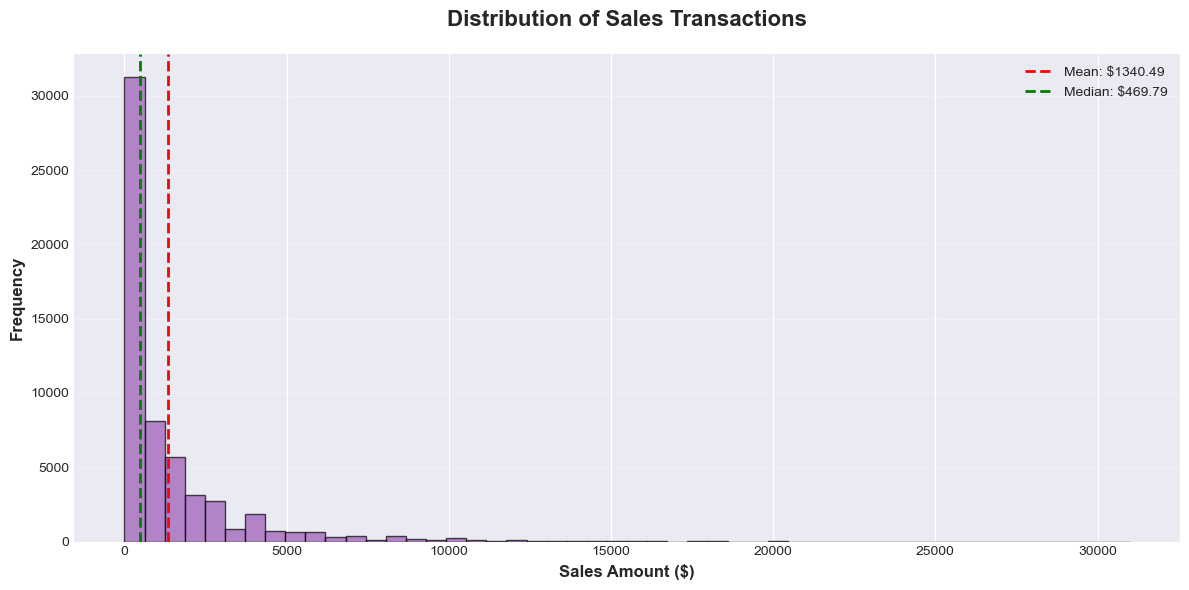

Chart 6 completed!


In [22]:
# Visualization: Sales Distribution (Histogram)

plt.figure(figsize=(12, 6))
plt.hist(df_master['Sales'], bins=50, color='#9B59B6', alpha=0.7, edgecolor='black')
plt.xlabel('Sales Amount ($)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Distribution of Sales Transactions', fontsize=16, fontweight='bold', pad=20)
plt.grid(axis='y', alpha=0.3)

# Add statistics
mean_sales = df_master['Sales'].mean()
median_sales = df_master['Sales'].median()
plt.axvline(mean_sales, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_sales:.2f}')
plt.axvline(median_sales, color='green', linestyle='--', linewidth=2, label=f'Median: ${median_sales:.2f}')
plt.legend()

save_plot('06_sales_distribution.png')
plt.show()

print("Chart 6 completed!")

Saved: C:\Users\HP\Desktop\AdventureWorks_2022\outputs\charts\07_sales_boxplot_category.png


<Figure size 1200x600 with 0 Axes>

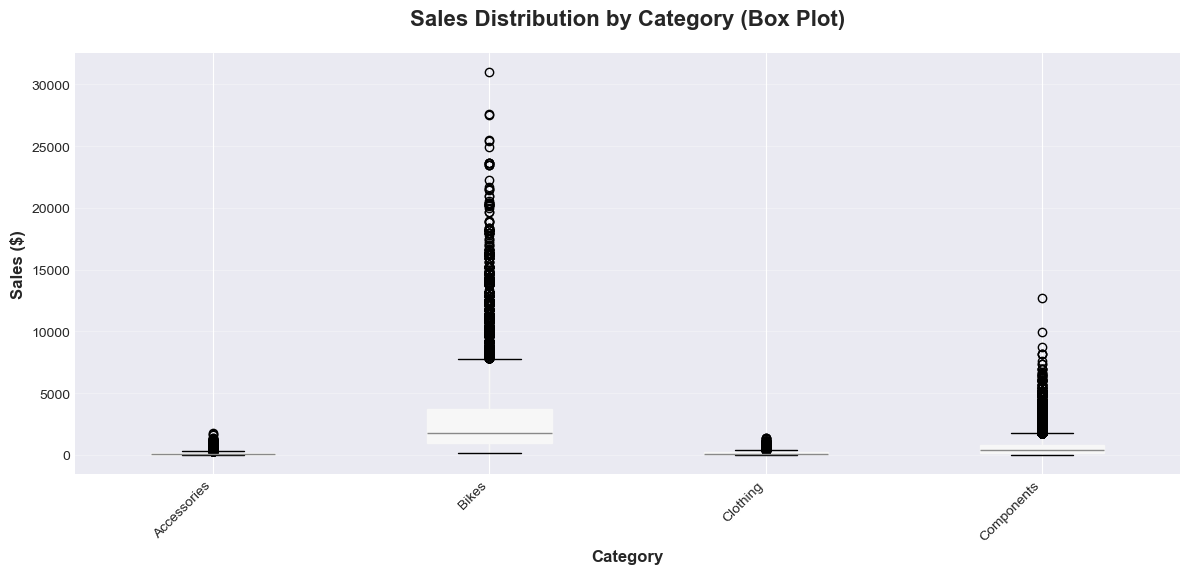

Chart 7 completed!


In [23]:
# Visualization: Sales by Category (Box Plot)

plt.figure(figsize=(12, 6))
df_master.boxplot(column='Sales', by='Category', figsize=(12, 6), patch_artist=True)
plt.xlabel('Category', fontsize=12, fontweight='bold')
plt.ylabel('Sales ($)', fontsize=12, fontweight='bold')
plt.title('Sales Distribution by Category (Box Plot)', fontsize=16, fontweight='bold', pad=20)
plt.suptitle('')  # Remove default title
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
save_plot('07_sales_boxplot_category.png')
plt.show()

print("Chart 7 completed!")

Saved: C:\Users\HP\Desktop\AdventureWorks_2022\outputs\charts\08_correlation_heatmap.png


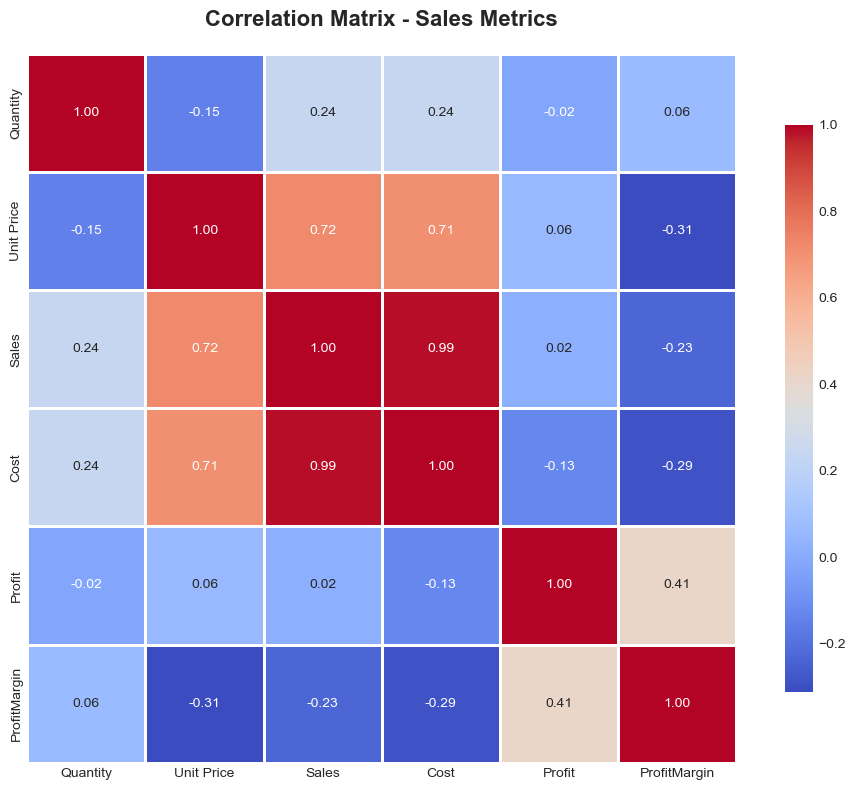

Chart 8 completed!


In [24]:
# Visualization: Correlation Heatmap

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Sales Metrics', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
save_plot('08_correlation_heatmap.png')
plt.show()

print("Chart 8 completed!")

Saved: C:\Users\HP\Desktop\AdventureWorks_2022\outputs\charts\09_quantity_vs_sales_scatter.png


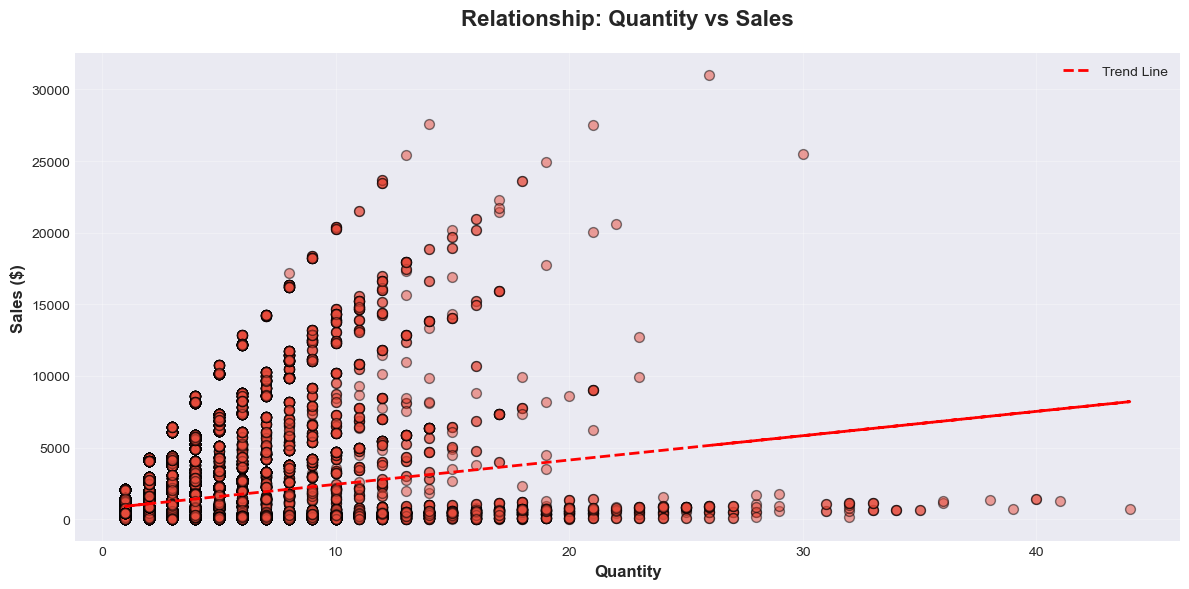

Chart 9 completed!


In [25]:
# Visualization: Quantity vs Sales (Scatter Plot)

plt.figure(figsize=(12, 6))
plt.scatter(df_master['Quantity'], df_master['Sales'], alpha=0.5, c='#E74C3C', edgecolors='black', s=50)
plt.xlabel('Quantity', fontsize=12, fontweight='bold')
plt.ylabel('Sales ($)', fontsize=12, fontweight='bold')
plt.title('Relationship: Quantity vs Sales', fontsize=16, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(df_master['Quantity'], df_master['Sales'], 1)
p = np.poly1d(z)
plt.plot(df_master['Quantity'], p(df_master['Quantity']), "r--", linewidth=2, label='Trend Line')
plt.legend()

save_plot('09_quantity_vs_sales_scatter.png')
plt.show()

print("Chart 9 completed!")

Saved: C:\Users\HP\Desktop\AdventureWorks_2022\outputs\charts\10_top15_subcategories.png


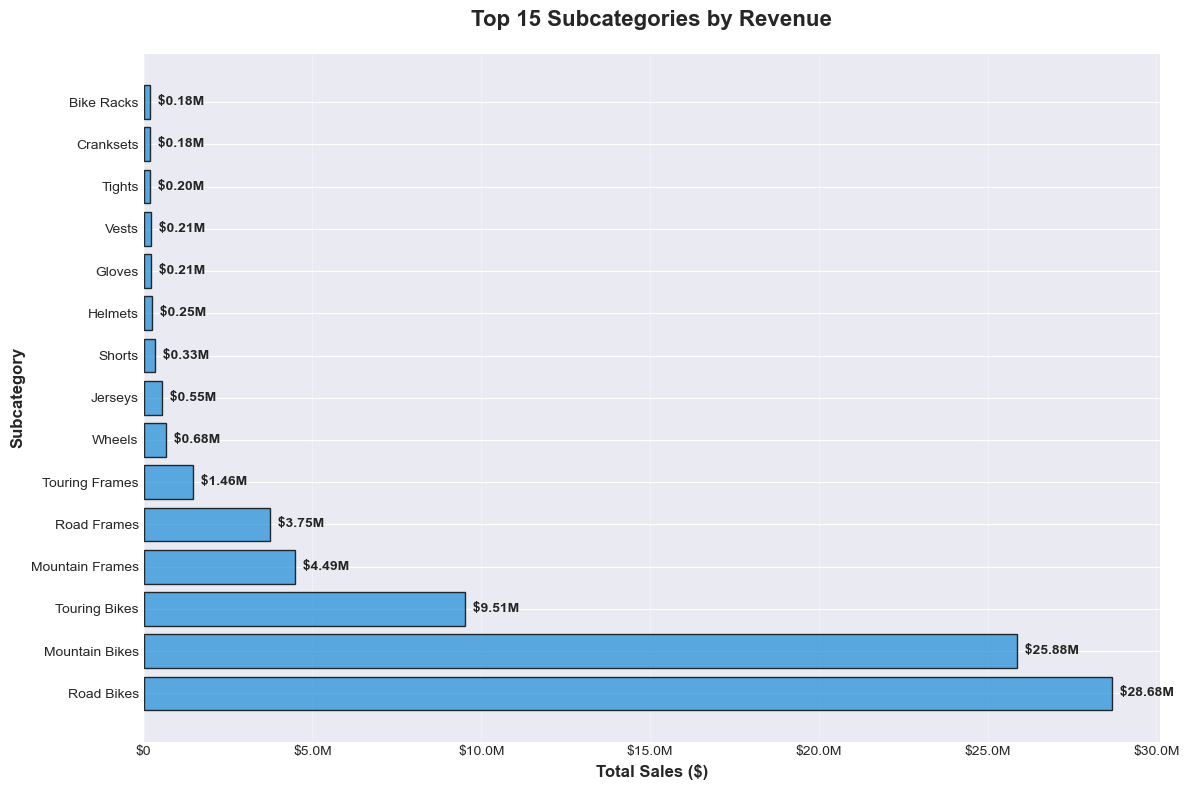

Chart 10 completed!


In [26]:
# Visualization: Subcategory Sales (Top 15)

subcategory_sales = df_master.groupby('Subcategory')['Sales'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
y_pos = np.arange(len(subcategory_sales))
plt.barh(y_pos, subcategory_sales.values, color='#3498DB', alpha=0.8, edgecolor='black')
plt.xlabel('Total Sales ($)', fontsize=12, fontweight='bold')
plt.ylabel('Subcategory', fontsize=12, fontweight='bold')
plt.title('Top 15 Subcategories by Revenue', fontsize=16, fontweight='bold', pad=20)
plt.yticks(y_pos, subcategory_sales.index, fontsize=10)
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(subcategory_sales.values):
    plt.text(v, i, f'  ${v/1e6:.2f}M', va='center', fontweight='bold')

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_currency))
save_plot('10_top15_subcategories.png')
plt.show()

print("Chart 10 completed!")

Saved: C:\Users\HP\Desktop\AdventureWorks_2022\outputs\charts\11_category_sales_over_time.png


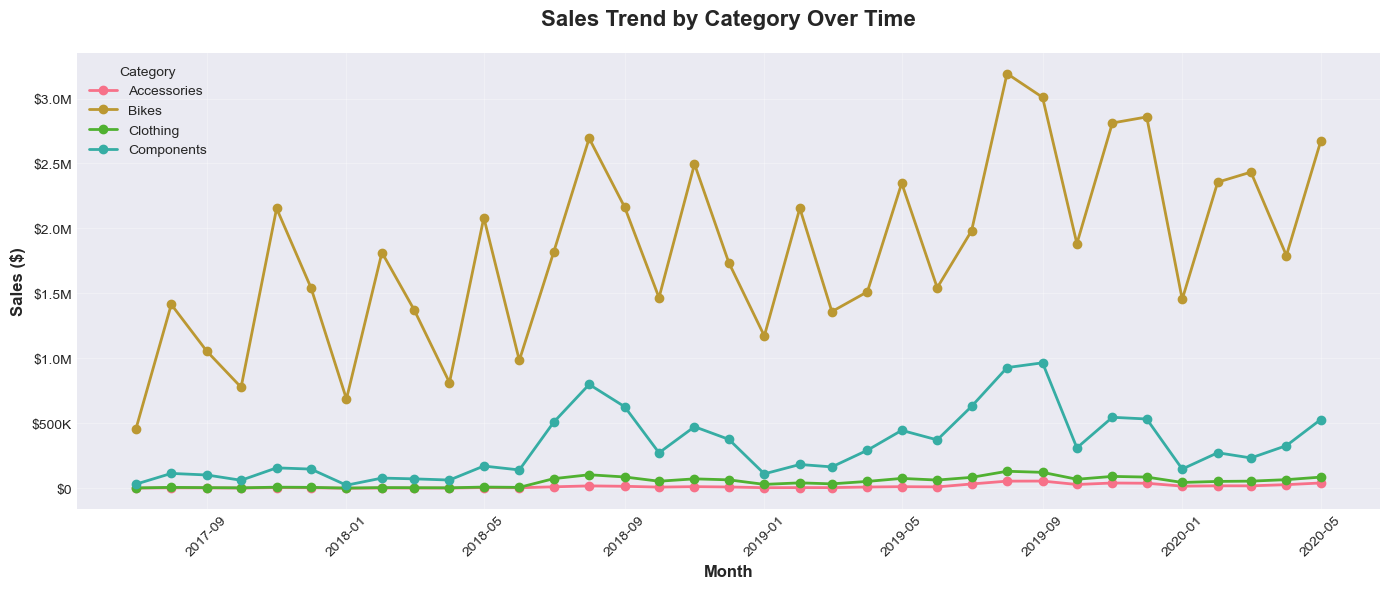

Chart 11 completed!


In [27]:
# Visualization: Sales by Category Over Time

# Prepare data - monthly sales by category
category_time = df_master.groupby([df_master['OrderDate'].dt.to_period('M'), 'Category'])['Sales'].sum().unstack()
category_time.index = category_time.index.to_timestamp()

plt.figure(figsize=(14, 6))
for category in category_time.columns:
    plt.plot(category_time.index, category_time[category], marker='o', linewidth=2, label=category)

plt.title('Sales Trend by Category Over Time', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Sales ($)', fontsize=12, fontweight='bold')
plt.legend(title='Category', loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_currency))
save_plot('11_category_sales_over_time.png')
plt.show()

print("Chart 11 completed!")

Saved: C:\Users\HP\Desktop\AdventureWorks_2022\outputs\charts\12_region_category_stacked.png


<Figure size 1400x700 with 0 Axes>

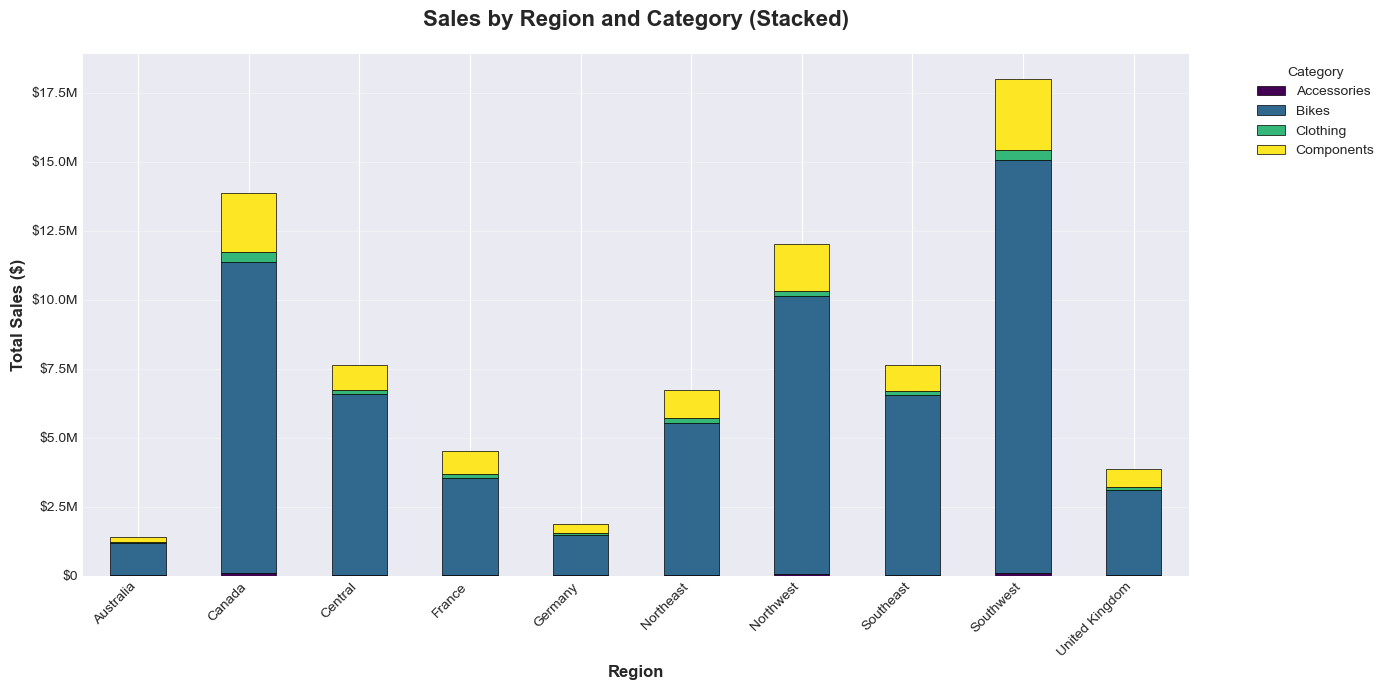

Chart 12 completed!


In [28]:
# Visualization: Sales by Region & Category (Stacked Bar)

# Prepare data
region_category = df_master.groupby(['Region', 'Category'])['Sales'].sum().unstack(fill_value=0)

plt.figure(figsize=(14, 7))
region_category.plot(kind='bar', stacked=True, figsize=(14, 7), 
                     colormap='viridis', edgecolor='black', linewidth=0.5)
plt.title('Sales by Region and Category (Stacked)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Region', fontsize=12, fontweight='bold')
plt.ylabel('Total Sales ($)', fontsize=12, fontweight='bold')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_currency))
plt.tight_layout()
save_plot('12_region_category_stacked.png')
plt.show()

print("Chart 12 completed!")

In [29]:
# Visualization:Salesperson Target Achievement

print("Analyzing Salesperson Target Achievement...")

# Aggregate actual sales by salesperson and month
actual_sales = df_master.groupby([df_master['OrderDate'].dt.to_period('M'), 'EmployeeKey'])['Sales'].sum().reset_index()
actual_sales.columns = ['Month', 'EmployeeKey', 'ActualSales']
actual_sales['Month'] = actual_sales['Month'].dt.to_timestamp()

# Merge salesperson info
actual_sales = actual_sales.merge(
    df_salesperson[['EmployeeKey', 'EmployeeID', 'Salesperson']], 
    on='EmployeeKey', 
    how='left'
)

# Prepare targets data
df_targets['Month'] = df_targets['TargetMonth'].dt.to_period('M').dt.to_timestamp()

# Merge actual with targets
achievement = actual_sales.merge(
    df_targets[['EmployeeID', 'Month', 'Target']], 
    on=['EmployeeID', 'Month'], 
    how='left'
)

# Calculate achievement percentage
achievement['Achievement_%'] = (achievement['ActualSales'] / achievement['Target']) * 100
achievement['Variance'] = achievement['ActualSales'] - achievement['Target']

# Summary by salesperson
salesperson_achievement = achievement.groupby('Salesperson').agg({
    'ActualSales': 'sum',
    'Target': 'sum',
    'Achievement_%': 'mean'
}).round(2)
salesperson_achievement['Overall_Achievement_%'] = (salesperson_achievement['ActualSales'] / salesperson_achievement['Target']) * 100

print("\nSalesperson Target Achievement Summary:")
print(salesperson_achievement.sort_values('Overall_Achievement_%', ascending=False))

#Ensure the folder exists
save_path = r"C:\Users\HP\Desktop\AdventureWorks_2022\data\processed"
os.makedirs(save_path, exist_ok=True)

# Export CSV
achievement.to_csv(os.path.join(save_path, 'salesperson_achievement.csv'), index=False)
print("\nSalesperson achievement data exported!")

Analyzing Salesperson Target Achievement...

Salesperson Target Achievement Summary:
                          ActualSales      Target  Achievement_%  \
Salesperson                                                        
Lynn Tsoflias              1216916.52   785000.00         213.65   
Jillian Carson             9755992.01  6375000.00         167.42   
Jae Pak                    8099816.95  6750000.00         196.90   
Ranjit Varkey Chudukatil   4429368.45  3750000.00         138.36   
Tsvi Reiter                6976128.29  6800000.00         111.11   
Rachel Valdez              1681207.53  1750000.00         101.98   
José Saraiva               5536439.26 12375000.00          52.35   
Michael Blythe             8952751.48 20350000.00          47.56   
Linda Mitchell            10158634.52 23500000.00          40.30   
Tete Mensa-Annan           2184211.15  6500000.00          33.18   
Syed Abbas                  174108.33   550000.00          35.16   
David Campbell             3614

In [33]:
#Export Cleaned Data for Excel & Power BI

print("Exporting cleaned datasets...")

# Absolute path for processed data
processed_path = r"C:\Users\HP\Desktop\AdventureWorks_2022\data\processed"

# Make sure folder exists
os.makedirs(processed_path, exist_ok=True)

# Export master dataset
df_master.to_csv(os.path.join(processed_path, 'master_dataset.csv'), index=False)
print("Master dataset exported: master_dataset.csv")


# Export aggregated datasets for easier analysis 

# 1. Monthly sales summary
monthly_summary = df_master.groupby(df_master['OrderDate'].dt.to_period('M')).agg({ 
    'Sales': 'sum', 
    'Profit': 'sum', 
    'Cost': 'sum', 
    'Quantity': 'sum', 
    'SalesOrderNumber': 'nunique' 
}).round(2) 
monthly_summary.index = monthly_summary.index.to_timestamp() 
monthly_summary.columns = ['Total_Sales', 'Total_Profit', 'Total_Cost', 'Total_Quantity', 'Total_Orders'] 
monthly_summary.to_csv(os.path.join(processed_path, 'monthly_sales_summary.csv')) 
print("Monthly summary exported: monthly_sales_summary.csv")



# 2. Product performance summary
product_summary = df_master.groupby( 
    ['ProductKey', 'Product', 'Category', 'Subcategory', 'Color']).agg({ 
    'Sales': 'sum', 
    'Profit': 'sum', 
    'Cost': 'sum', 
    'Quantity': 'sum', 
    'SalesOrderNumber': 'nunique' 
}).round(2).reset_index() 

product_summary.columns = [ 
    'ProductKey', 'Product', 'Category', 'Subcategory', 'Color', 
    'Total_Sales', 'Total_Profit', 'Total_Cost', 'Total_Quantity', 'Total_Orders' 
] 

product_summary['Profit_Margin_%'] = ( 
    product_summary['Total_Profit'] / product_summary['Total_Sales'] * 100 
).round(2) 
product_summary.to_csv(os.path.join(processed_path, 'product_summary.csv'), index=False) 
print("Product summary exported: product_summary.csv") 


# 3. Regional performance summary
region_summary = df_master.groupby( 
    ['Region', 'Country']).agg({ 
    'Sales': 'sum', 
    'Profit': 'sum', 
    'Quantity': 'sum', 
    'SalesOrderNumber': 'nunique' 
}).round(2).reset_index() 
region_summary.columns = ['Region', 'Country', 'Total_Sales', 'Total_Profit', 'Total_Quantity', 'Total_Orders'] 
region_summary.to_csv(os.path.join(processed_path, 'region_summary.csv'), index=False) 
print("Regional summary exported: region_summary.csv")


# 4. Salesperson performance summary
salesperson_summary = df_master.groupby( 
    ['EmployeeKey', 'Salesperson', 'Title']).agg({ 
    'Sales': 'sum', 
    'Profit': 'sum', 
    'Quantity': 'sum', 
    'SalesOrderNumber': 'nunique' 
}).round(2).reset_index() 
salesperson_summary.columns = [ 
    'EmployeeKey', 'Salesperson', 'Title', 
    'Total_Sales', 'Total_Profit', 'Total_Quantity', 'Total_Orders' 
] 
salesperson_summary.to_csv(os.path.join(processed_path, 'salesperson_summary.csv'), index=False) 
print("Salesperson summary exported: salesperson_summary.csv")


# 5. Reseller performance summary
reseller_summary = df_master.groupby(
    ['ResellerKey', 'Reseller', 'Business Type', 'Country-Region']
).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'SalesOrderNumber': 'nunique'
}).round(2).reset_index()

reseller_summary.columns = [
    'ResellerKey', 'Reseller', 'Business_Type', 'Country',
    'Total_Sales', 'Total_Profit', 'Total_Orders'
]

reseller_summary.to_csv(os.path.join(processed_path, 'reseller_summary.csv'), index=False)
print("Reseller summary exported: reseller_summary.csv")


print("\nAll datasets exported successfully!")
print(f"Files saved in: {processed_path}")

Exporting cleaned datasets...
Master dataset exported: master_dataset.csv
Monthly summary exported: monthly_sales_summary.csv
Product summary exported: product_summary.csv
Regional summary exported: region_summary.csv
Salesperson summary exported: salesperson_summary.csv
Reseller summary exported: reseller_summary.csv

All datasets exported successfully!
Files saved in: C:\Users\HP\Desktop\AdventureWorks_2022\data\processed


In [35]:
#Analysis Summary Report

print("="*80)
print(" " * 20 + "ADVENTURE WORKS 2022 - ANALYSIS SUMMARY REPORT")
print("="*80)

print("\nDATASET OVERVIEW")
print("-" * 80)
print(f"Total Records in Master Dataset: {len(df_master):,}")
print(f"Date Range: {df_master['OrderDate'].min().strftime('%B %d, %Y')} to {df_master['OrderDate'].max().strftime('%B %d, %Y')}")
print(f"Analysis Period: {(df_master['OrderDate'].max() - df_master['OrderDate'].min()).days} days")

print("\nKEY FINANCIAL METRICS")
print("-" * 80)
total_revenue = df_master['Sales'].sum()
total_cost = df_master['Cost'].sum()
total_profit = df_master['Profit'].sum()
avg_profit_margin = df_master['ProfitMargin'].mean()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Cost: ${total_cost:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Average Profit Margin: {avg_profit_margin:.2f}%")
print(f"Total Orders: {df_master['SalesOrderNumber'].nunique():,}")
print(f"Total Units Sold: {df_master['Quantity'].sum():,}")
print(f"Average Order Value: ${df_master['Sales'].mean():,.2f}")

print("\nBUSINESS DIMENSIONS")
print("-" * 80)
print(f"Total Products: {df_master['Product'].nunique()}")
print(f"Total Categories: {df_master['Category'].nunique()}")
print(f"Total Subcategories: {df_master['Subcategory'].nunique()}")
print(f"Total Resellers: {df_master['Reseller'].nunique()}")
print(f"Total Salespeople: {df_master['Salesperson'].nunique()}")
print(f"Total Regions: {df_master['Region'].nunique()}")
print(f"Total Countries: {df_master['Country'].nunique()}")

print("\nTOP PERFORMERS")
print("-" * 80)
print(f"\nTop Product: {top_products.index[0]}")
print(f"  Revenue: ${top_products.iloc[0]['Total_Sales']:,.2f}")

print(f"\nTop Category: {category_sales.index[0]}")
print(f"  Revenue: ${category_sales.iloc[0]['Total_Sales']:,.2f}")

print(f"\nTop Region: {region_sales.index[0]}")
print(f"  Revenue: ${region_sales.iloc[0]['Total_Sales']:,.2f}")

print(f"\nTop Salesperson: {top_salespeople.index[0]}")
print(f"  Revenue: ${top_salespeople.iloc[0]['Total_Sales']:,.2f}")

print(f"\nTop Reseller: {top_resellers.index[0]}")
print(f"  Revenue: ${top_resellers.iloc[0]['Total_Sales']:,.2f}")

print("\nGROWTH ANALYSIS")
print("-" * 80)
if len(yearly_sales) > 1:
    latest_year = yearly_sales.index[-1]
    prev_year = yearly_sales.index[-2]
    yoy_growth = yearly_sales.loc[latest_year, 'Sales_Growth_%']
    print(f"Year-over-Year Sales Growth ({prev_year} to {latest_year}): {yoy_growth:.2f}%")
else:
    print("Insufficient data for YoY comparison")

print("\nCATEGORY PERFORMANCE")
print("-" * 80)
for idx, row in category_sales.iterrows():
    pct = (row['Total_Sales'] / total_revenue) * 100
    print(f"{idx}: ${row['Total_Sales']:,.2f} ({pct:.1f}% of total)")

print("\nREGIONAL BREAKDOWN")
print("-" * 80)
for idx, row in region_sales.head().iterrows():
    pct = (row['Total_Sales'] / total_revenue) * 100
    print(f"{idx}: ${row['Total_Sales']:,.2f} ({pct:.1f}% of total)")

print("\n" + "="*80)
print(" " * 30 + "END OF REPORT")
print("="*80)


# Save report to text file
# Absolute path for the report
report_path = r"C:\Users\HP\Desktop\AdventureWorks_2022\outputs\reports"
os.makedirs(report_path, exist_ok=True)  # Ensure folder exists

report_file = os.path.join(report_path, 'analysis_summary.txt')

# Save report to text file
original_stdout = sys.stdout
with open(report_file, 'w') as f:
    sys.stdout = f
    # Copy all report print statements here
    print("="*80)
    print(" " * 20 + "ADVENTURE WORKS 2022 - ANALYSIS SUMMARY REPORT")
    print("="*80)
    # ... rest of your report content
sys.stdout = original_stdout

print(f"\nReport saved to: {report_file}")

                    ADVENTURE WORKS 2022 - ANALYSIS SUMMARY REPORT

DATASET OVERVIEW
--------------------------------------------------------------------------------
Total Records in Master Dataset: 57,851
Date Range: July 01, 2017 to May 31, 2020
Analysis Period: 1065 days

KEY FINANCIAL METRICS
--------------------------------------------------------------------------------
Total Revenue: $77,548,570.20
Total Cost: $76,549,075.63
Total Profit: $999,494.57
Average Profit Margin: 8.97%
Total Orders: 3,616
Total Units Sold: 204,114
Average Order Value: $1,340.49

BUSINESS DIMENSIONS
--------------------------------------------------------------------------------
Total Products: 250
Total Categories: 4
Total Subcategories: 33
Total Resellers: 630
Total Salespeople: 17
Total Regions: 10
Total Countries: 6

TOP PERFORMERS
--------------------------------------------------------------------------------

Top Product: Mountain-200 Black, 38
  Revenue: $2,944,665.88

Top Category: Bikes
  Reve

In [38]:
#Key Insights & Business Recommendations

# ============================================
# KEY INSIGHTS & BUSINESS RECOMMENDATIONS
# ============================================

print("="*80)
print(" " * 25 + "KEY INSIGHTS & RECOMMENDATIONS")
print("="*80)

print("\nKEY INSIGHTS")
print("-" * 80)

# Insight 1: Category Performance
top_category = category_sales.index[0]
top_category_pct = (category_sales.iloc[0]['Total_Sales'] / total_revenue) * 100
print(f"\n1. CATEGORY DOMINANCE")
print(f"   • {top_category} is the leading category, representing {top_category_pct:.1f}% of total revenue")
print(f"   • Total sales: ${category_sales.iloc[0]['Total_Sales']:,.2f}")

# Insight 2: Regional Performance
top_region = region_sales.index[0]
bottom_region = region_sales.index[-1]
print(f"\n2. REGIONAL DISPARITY")
print(f"   • {top_region} leads with ${region_sales.iloc[0]['Total_Sales']:,.2f}")
print(f"   • {bottom_region} shows ${region_sales.iloc[-1]['Total_Sales']:,.2f}")
print(f"   • Gap: ${(region_sales.iloc[0]['Total_Sales'] - region_sales.iloc[-1]['Total_Sales']):,.2f}")

# Insight 3: Profit Margin
high_margin_products = df_master.groupby('Product')['ProfitMargin'].mean().sort_values(ascending=False).head(3)
print(f"\n3. PROFITABILITY")
print(f"   • Average profit margin: {avg_profit_margin:.2f}%")
print(f"   • Highest margin products:")
for prod, margin in high_margin_products.items():
    print(f"     - {prod}: {margin:.2f}%")

# Insight 4: Sales Trend
monthly_growth = ((monthly_sales['Total_Sales'].iloc[-1] - monthly_sales['Total_Sales'].iloc[0]) / 
                  monthly_sales['Total_Sales'].iloc[0] * 100)
print(f"\n4. SALES TREND")
print(f"   • Overall growth: {monthly_growth:.2f}%")
print(f"   • First month sales: ${monthly_sales['Total_Sales'].iloc[0]:,.2f}")
print(f"   • Latest month sales: ${monthly_sales['Total_Sales'].iloc[-1]:,.2f}")

# Insight 5: Customer Concentration
top_10_resellers_pct = (top_resellers['Total_Sales'].sum() / total_revenue) * 100
print(f"\n5. CUSTOMER CONCENTRATION")
print(f"   • Top 10 resellers contribute {top_10_resellers_pct:.1f}% of total revenue")
print(f"   • Total resellers: {df_master['Reseller'].nunique()}")

print("\n\nBUSINESS RECOMMENDATIONS")
print("-" * 80)

print("\n1. EXPAND HIGH-PERFORMING CATEGORIES")
print(f"   • Invest more in {top_category} product line")
print("   • Increase inventory for top-selling products")
print("   • Consider product line extensions")

print("\n2. ADDRESS REGIONAL DISPARITIES")
print(f"   • Investigate why {bottom_region} is underperforming")
print("   • Replicate successful strategies from top regions")
print("   • Consider targeted marketing campaigns")

print("\n3. OPTIMIZE PRODUCT MIX")
print("   • Focus on high-margin products")
print("   • Phase out low-margin items")
print("   • Bundle high and low margin products strategically")

print("\n4. STRENGTHEN KEY RELATIONSHIPS")
print("   • Develop loyalty programs for top resellers")
print("   • Offer volume discounts to maintain relationships")
print("   • Regular business reviews with top 20% of customers")

print("\n5. ENHANCE SALES TEAM PERFORMANCE")
print("   • Provide additional training to underperforming salespeople")
print("   • Implement mentorship programs")
print("   • Review and adjust sales targets based on regional potential")

print("\n6. INVENTORY MANAGEMENT")
print("   • Stock more of high-velocity products")
print("   • Reduce inventory of slow-moving items")
print("   • Implement just-in-time for seasonal products")

print("\n" + "="*80)
print(" " * 35 + "END OF INSIGHTS")
print("="*80)

#saving the file
# Folder path for saving the report
report_path = r"C:\Users\HP\Desktop\AdventureWorks_2022\outputs\reports"
os.makedirs(report_path, exist_ok=True)

# File path for Key Insights report
report_file = os.path.join(report_path, 'key_insights.txt')

# Save report to text file
original_stdout = sys.stdout
with open(report_file, 'w') as f:
    sys.stdout = f
    
    # Copy all your Key Insights & Recommendations print statements here
    print("="*80)
    print(" " * 25 + "KEY INSIGHTS & RECOMMENDATIONS")
    print("="*80)
    # ... paste all the Key Insights & Recommendations prints here
    
# Reset stdout
sys.stdout = original_stdout

print(f"\nKey Insights report saved to: {report_file}")

                         KEY INSIGHTS & RECOMMENDATIONS

KEY INSIGHTS
--------------------------------------------------------------------------------

1. CATEGORY DOMINANCE
   • Bikes is the leading category, representing 82.6% of total revenue
   • Total sales: $64,069,033.16

2. REGIONAL DISPARITY
   • Southwest leads with $18,001,116.10
   • Australia shows $1,391,024.85
   • Gap: $16,610,091.25

3. PROFITABILITY
   • Average profit margin: 8.97%
   • Highest margin products:
     - Mountain Bike Socks, L: 40.39%
     - Mountain Bike Socks, M: 39.91%
     - Classic Vest, L: 37.66%

4. SALES TREND
   • Overall growth: 580.24%
   • First month sales: $489,328.40
   • Latest month sales: $3,328,607.46

5. CUSTOMER CONCENTRATION
   • Top 10 resellers contribute 10.0% of total revenue
   • Total resellers: 630


BUSINESS RECOMMENDATIONS
--------------------------------------------------------------------------------

1. EXPAND HIGH-PERFORMING CATEGORIES
   • Invest more in Bikes product